# 🔄 02 — ETL Pipeline & Feature Engineering

**E-Commerce Customer Behavior Analysis & Hybrid Recommendation System**

---

## Pipeline Overview
1. **Extract** — Load raw datasets
2. **Transform** — Clean, handle missing values, outliers, feature engineering
3. **Load** — Populate MySQL Star Schema + generate merged dataset

In [1]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_GENERATED = Path('../data/generated')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_GENERATED.mkdir(parents=True, exist_ok=True)

print('✅ Ready')

✅ Ready


---
## PART 1: EXTRACT — Load Raw Data

In [2]:
# ============================================================
# 1.1 Load Online Retail II
# ============================================================
retail_path = DATA_RAW / 'online_retail' / 'online_retail_II.xlsx'
df_y1 = pd.read_excel(retail_path, sheet_name='Year 2009-2010')
df_y2 = pd.read_excel(retail_path, sheet_name='Year 2010-2011')
df_retail = pd.concat([df_y1, df_y2], ignore_index=True)
print(f'Retail: {df_retail.shape}')
df_retail.head(2)

Retail: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [3]:
# ============================================================
# 1.2 Load Reviews
# ============================================================
df_reviews = pd.read_csv(DATA_RAW / 'clothing_reviews' / 'Womens Clothing E-Commerce Reviews.csv')
print(f'Reviews: {df_reviews.shape}')
df_reviews.head(2)

Reviews: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses


---
## PART 2: TRANSFORM — Data Cleaning

### 2.1 Clean Online Retail II

In [4]:
# ============================================================
# 2.1.1 Before cleaning stats
# ============================================================
print(f'Before cleaning: {df_retail.shape}')
print(f'Missing values:\n{df_retail.isnull().sum()}')
print(f'\nDuplicates: {df_retail.duplicated().sum()}')

Before cleaning: (1067371, 8)
Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicates: 34335


In [5]:
# ============================================================
# 2.1.2 Remove cancelled orders (Invoice starts with 'C')
# ============================================================
df_retail['Invoice'] = df_retail['Invoice'].astype(str)
cancelled = df_retail[df_retail['Invoice'].str.startswith('C')]
print(f'Cancelled orders: {len(cancelled)} ({len(cancelled)/len(df_retail)*100:.1f}%)')

# Save cancellations separately for analysis
cancelled.to_csv(DATA_PROCESSED / 'retail_cancellations.csv', index=False)

# Keep only valid orders
df_retail = df_retail[~df_retail['Invoice'].str.startswith('C')].copy()
print(f'After removing cancellations: {df_retail.shape}')

Cancelled orders: 19494 (1.8%)
After removing cancellations: (1047877, 8)


In [6]:
# ============================================================
# 2.1.3 Drop rows with missing Customer ID
# ============================================================
null_customers = df_retail['Customer ID'].isnull().sum()
print(f'Rows with null Customer ID: {null_customers} ({null_customers/len(df_retail)*100:.1f}%)')
df_retail = df_retail.dropna(subset=['Customer ID']).copy()
df_retail['Customer ID'] = df_retail['Customer ID'].astype(int)
print(f'After dropping null customers: {df_retail.shape}')

Rows with null Customer ID: 242257 (23.1%)
After dropping null customers: (805620, 8)


In [7]:
# ============================================================
# 2.1.4 Remove duplicates
# ============================================================
dupes = df_retail.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df_retail = df_retail.drop_duplicates().copy()
print(f'After dedup: {df_retail.shape}')

Duplicate rows: 26125
After dedup: (779495, 8)


In [8]:
# ============================================================
# 2.1.5 Filter negative/zero Quantity and Price
# ============================================================
neg_qty = (df_retail['Quantity'] <= 0).sum()
neg_price = (df_retail['Price'] <= 0).sum()
print(f'Negative/zero Quantity: {neg_qty}')
print(f'Negative/zero Price: {neg_price}')

df_retail = df_retail[(df_retail['Quantity'] > 0) & (df_retail['Price'] > 0)].copy()
print(f'After filtering: {df_retail.shape}')

Negative/zero Quantity: 0
Negative/zero Price: 70
After filtering: (779425, 8)


In [9]:
# ============================================================
# 2.1.6 Handle outliers using IQR method
# ============================================================
def remove_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before = len(df)
    df = df[(df[column] >= lower) & (df[column] <= upper)].copy()
    removed = before - len(df)
    print(f'  {column}: removed {removed} outliers (range: {lower:.2f} to {upper:.2f})')
    return df

print('Removing outliers (IQR method):')
df_retail = remove_outliers_iqr(df_retail, 'Quantity')
df_retail = remove_outliers_iqr(df_retail, 'Price')
print(f'After outlier removal: {df_retail.shape}')

Removing outliers (IQR method):
  Quantity: removed 51119 outliers (range: -13.00 to 27.00)
  Price: removed 64933 outliers (range: -2.50 to 7.50)
After outlier removal: (663373, 8)


In [10]:
# ============================================================
# 2.1.7 Compute TotalPrice & extract time features
# ============================================================
df_retail['TotalPrice'] = df_retail['Quantity'] * df_retail['Price']
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])
df_retail['Year'] = df_retail['InvoiceDate'].dt.year
df_retail['Month'] = df_retail['InvoiceDate'].dt.month
df_retail['DayOfWeek'] = df_retail['InvoiceDate'].dt.day_name()
df_retail['Hour'] = df_retail['InvoiceDate'].dt.hour
df_retail['IsWeekend'] = df_retail['InvoiceDate'].dt.dayofweek.isin([5, 6]).astype(int)
df_retail['Quarter'] = df_retail['InvoiceDate'].dt.quarter

print('Time features added ✅')
print(f'Date range: {df_retail["InvoiceDate"].min()} → {df_retail["InvoiceDate"].max()}')
df_retail.head(3)

Time features added ✅
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayOfWeek,Hour,IsWeekend,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Tuesday,7,0,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday,7,0,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday,7,0,4


In [11]:
# ============================================================
# 2.1.8 Clean Description column
# ============================================================
df_retail['Description'] = df_retail['Description'].fillna('UNKNOWN')
df_retail['Description'] = df_retail['Description'].str.strip().str.upper()
print(f'Unique products: {df_retail["StockCode"].nunique()}')
print(f'Unique descriptions: {df_retail["Description"].nunique()}')

Unique products: 4254
Unique descriptions: 4796


In [12]:
# ============================================================
# 2.1.9 Summary after cleaning
# ============================================================
print('=== RETAIL CLEANING SUMMARY ===')
print(f'Final shape: {df_retail.shape}')
print(f'Missing values: {df_retail.isnull().sum().sum()}')
print(f'Customers: {df_retail["Customer ID"].nunique()}')
print(f'Products: {df_retail["StockCode"].nunique()}')
print(f'Countries: {df_retail["Country"].nunique()}')
print(f'Total Revenue: £{df_retail["TotalPrice"].sum():,.2f}')

# Save cleaned retail
df_retail.to_csv(DATA_PROCESSED / 'retail_clean.csv', index=False)
print('\n✅ Saved: data/processed/retail_clean.csv')

=== RETAIL CLEANING SUMMARY ===
Final shape: (663373, 15)
Missing values: 0
Customers: 5675
Products: 4254
Countries: 41
Total Revenue: £8,628,508.94

✅ Saved: data/processed/retail_clean.csv


### 2.2 Clean Reviews Dataset

In [13]:
# ============================================================
# 2.2.1 Inspect & clean reviews
# ============================================================
print(f'Before: {df_reviews.shape}')
print(f'Columns: {list(df_reviews.columns)}')
print(f'Missing:\n{df_reviews.isnull().sum()}')

# Drop unnamed index column if present
if 'Unnamed: 0' in df_reviews.columns:
    df_reviews = df_reviews.drop('Unnamed: 0', axis=1)

# Rename columns for consistency
df_reviews.columns = [c.strip().replace(' ', '_') for c in df_reviews.columns]
print(f'\nRenamed columns: {list(df_reviews.columns)}')

Before: (23486, 11)
Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']
Missing:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Renamed columns: ['Clothing_ID', 'Age', 'Title', 'Review_Text', 'Rating', 'Recommended_IND', 'Positive_Feedback_Count', 'Division_Name', 'Department_Name', 'Class_Name']


In [14]:
# ============================================================
# 2.2.2 Handle missing values in reviews
# ============================================================
# Find the review text column
text_cols = [c for c in df_reviews.columns if 'review' in c.lower() and 'text' in c.lower()]
if not text_cols:
    text_cols = [c for c in df_reviews.columns if 'review' in c.lower()]
review_text_col = text_cols[0] if text_cols else None

print(f'Review text column: {review_text_col}')

# Drop rows with no review text
if review_text_col:
    before = len(df_reviews)
    df_reviews = df_reviews.dropna(subset=[review_text_col]).copy()
    print(f'Dropped {before - len(df_reviews)} rows with no review text')

# Fill other missing values
for col in df_reviews.select_dtypes(include='object').columns:
    df_reviews[col] = df_reviews[col].fillna('Unknown')
for col in df_reviews.select_dtypes(include='number').columns:
    df_reviews[col] = df_reviews[col].fillna(df_reviews[col].median())

print(f'After cleaning: {df_reviews.shape}')
print(f'Missing: {df_reviews.isnull().sum().sum()}')

Review text column: Review_Text
Dropped 845 rows with no review text
After cleaning: (22641, 10)
Missing: 0


In [15]:
# ============================================================
# 2.2.3 Clean review text
# ============================================================
if review_text_col:
    df_reviews[review_text_col] = (
        df_reviews[review_text_col]
        .str.lower()
        .str.strip()
    )
    df_reviews['ReviewLength'] = df_reviews[review_text_col].str.split().str.len()
    print(f'Avg review length: {df_reviews["ReviewLength"].mean():.1f} words')
    print(f'Min: {df_reviews["ReviewLength"].min()}, Max: {df_reviews["ReviewLength"].max()}')

# Save cleaned reviews
df_reviews.to_csv(DATA_PROCESSED / 'reviews_clean.csv', index=False)
print('\n✅ Saved: data/processed/reviews_clean.csv')

Avg review length: 60.2 words
Min: 2, Max: 115

✅ Saved: data/processed/reviews_clean.csv


---
## PART 3: FEATURE ENGINEERING — RFM & Customer Features

In [16]:
# ============================================================
# 3.1 Compute RFM (Recency, Frequency, Monetary)
# ============================================================
# Reference date = day after last transaction
reference_date = df_retail['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date}')

rfm = df_retail.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm['Customer ID'] = rfm['Customer ID'].astype(int)

print(f'\nRFM Table: {rfm.shape}')
print(rfm.describe().round(2))
rfm.head()

Reference date: 2011-12-10 12:50:00

RFM Table: (5675, 4)
       Customer ID  Recency  Frequency   Monetary
count      5675.00  5675.00    5675.00    5675.00
mean      15319.48   200.79       5.88    1520.44
std        1714.85   208.74      11.50    3740.79
min       12346.00     1.00       1.00       1.90
25%       13837.50    26.00       1.00     246.27
50%       15321.00    95.00       3.00     604.50
75%       16802.50   380.00       6.00    1542.86
max       18287.00   739.00     367.00  174896.61


,Customer ID,Recency,Frequency,Monetary
0,12346,529,11,372.86
1,12347,2,8,3888.01
2,12348,249,4,312.36
3,12349,19,3,2635.04
4,12350,310,1,294.40


In [17]:
# ============================================================
# 3.2 Churn Label (Recency > 90 days = churned)
# ============================================================
CHURN_THRESHOLD = 90  # days
rfm['ChurnLabel'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

churn_rate = rfm['ChurnLabel'].mean() * 100
print(f'Churn threshold: {CHURN_THRESHOLD} days')
print(f'Churned customers: {rfm["ChurnLabel"].sum()} ({churn_rate:.1f}%)')
print(f'Active customers: {(rfm["ChurnLabel"]==0).sum()} ({100-churn_rate:.1f}%)')

Churn threshold: 90 days
Churned customers: 2873 (50.6%)
Active customers: 2802 (49.4%)


In [18]:
# ============================================================
# 3.3 Additional Customer Features
# ============================================================
# Average order value
rfm['AvgOrderValue'] = (rfm['Monetary'] / rfm['Frequency']).round(2)

# Customer first/last purchase dates
date_features = df_retail.groupby('Customer ID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
    TotalItems=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    UniqueCountries=('Country', 'nunique')
).reset_index()

date_features['Customer ID'] = date_features['Customer ID'].astype(int)
date_features['DaysSinceFirstPurchase'] = (reference_date - date_features['FirstPurchase']).dt.days
date_features['CustomerLifespan'] = (date_features['LastPurchase'] - date_features['FirstPurchase']).dt.days

# Favorite category (most purchased product description)
fav_product = (
    df_retail.groupby(['Customer ID', 'Description'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates(subset='Customer ID', keep='first')
    [['Customer ID', 'Description']]
    .rename(columns={'Description': 'FavoriteProduct'})
)
fav_product['Customer ID'] = fav_product['Customer ID'].astype(int)

# Country
customer_country = (
    df_retail.groupby('Customer ID')['Country']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)
customer_country['Customer ID'] = customer_country['Customer ID'].astype(int)

# Merge all
customer_features = (
    rfm
    .merge(date_features[['Customer ID', 'TotalItems', 'UniqueProducts', 
                          'DaysSinceFirstPurchase', 'CustomerLifespan']], on='Customer ID')
    .merge(fav_product, on='Customer ID', how='left')
    .merge(customer_country, on='Customer ID', how='left')
)

print(f'Customer features table: {customer_features.shape}')
print(f'Columns: {list(customer_features.columns)}')
customer_features.head()

Customer features table: (5675, 12)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'ChurnLabel', 'AvgOrderValue', 'TotalItems', 'UniqueProducts', 'DaysSinceFirstPurchase', 'CustomerLifespan', 'FavoriteProduct', 'Country']


,Customer ID,Recency,Frequency,Monetary,ChurnLabel,AvgOrderValue,TotalItems,UniqueProducts,DaysSinceFirstPurchase,CustomerLifespan,FavoriteProduct,Country
0,12346,529,11,372.86,1,33.90,70,26,726,196,THIS IS A TEST PRODUCT.,United Kingdom
1,12347,2,8,3888.01,0,486.00,2399,119,404,402,AIRLINE BAG VINTAGE JET SET BROWN,Iceland
2,12348,249,4,312.36,1,78.09,513,21,438,189,PACK OF 60 PINK PAISLEY CAKE CASES,Finland
3,12349,19,3,2635.04,0,878.35,1421,111,589,570,PLASTERS IN TIN STRONGMAN,Italy
4,12350,310,1,294.40,1,294.40,196,16,310,0,RED HARMONICA IN BOX,Norway


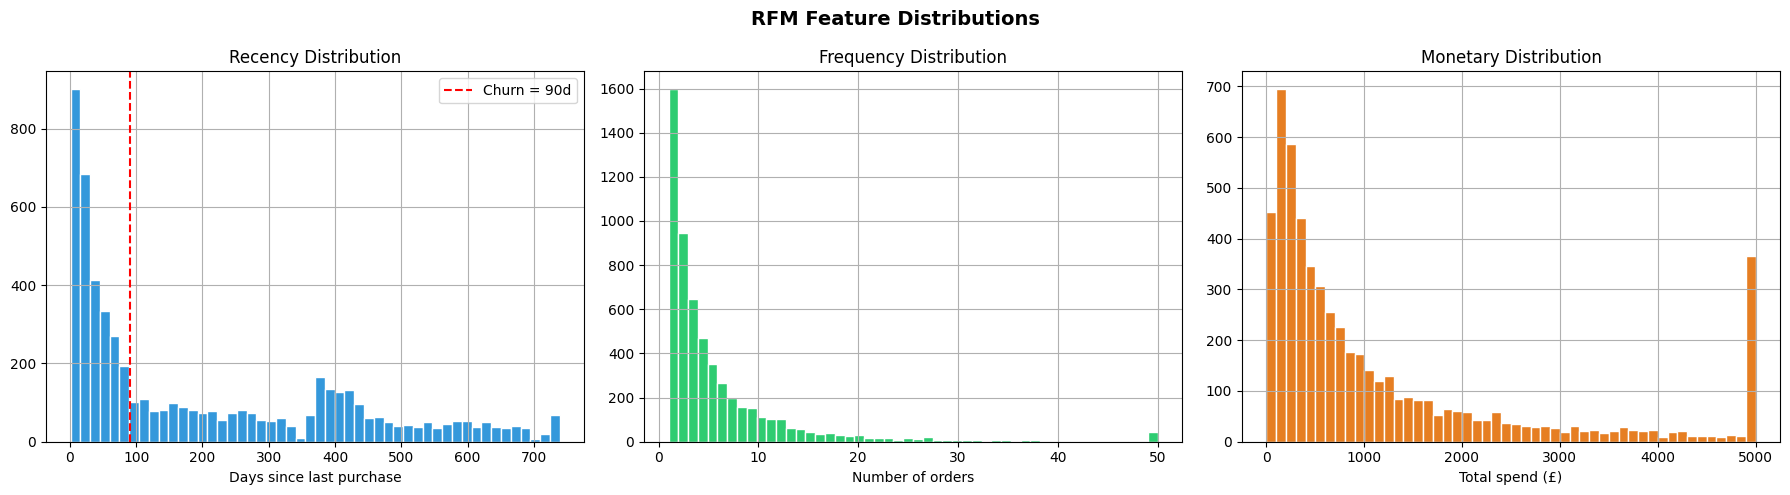

In [19]:
# ============================================================
# 3.4 RFM Visualizations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rfm['Recency'].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')
axes[0].axvline(x=CHURN_THRESHOLD, color='red', linestyle='--', label=f'Churn = {CHURN_THRESHOLD}d')
axes[0].legend()

rfm['Frequency'].clip(0, 50).hist(bins=50, ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

rfm['Monetary'].clip(0, 5000).hist(bins=50, ax=axes[2], color='#e67e22', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/etl_rfm_distributions.png', dpi=150)
plt.show()

In [23]:
# ============================================================
# 4.9 Verify Data in MySQL
# ============================================================
print('=== DATA WAREHOUSE SUMMARY ===')
tables = ['Dim_Customer', 'Dim_Product', 'Dim_Time', 'Dim_Location', 'Fact_Orders']
for table in tables:
    count = pd.read_sql(f'SELECT COUNT(*) as cnt FROM {table}', engine).iloc[0, 0]
    print(f'  {table}: {count:,} rows')

print('\n✅ ETL Pipeline Complete!')

=== DATA WAREHOUSE SUMMARY ===
  Dim_Customer: 5,878 rows
  Dim_Product: 4,630 rows
  Dim_Time: 604 rows
  Dim_Location: 41 rows
  Fact_Orders: 779,403 rows

✅ ETL Pipeline Complete!


---
## ETL Summary

| Step | Input | Output |
|------|-------|--------|
| Extract | 3 raw datasets | Loaded DataFrames |
| Transform | Raw data | Cleaned + feature-engineered data |
| Load | Clean data → MySQL Star Schema | 4 Dimensions + 1 Fact table |
| Generate | DW queries → merged dataset | `customer_features.csv` |

### Files Created:
- `data/processed/retail_clean.csv`
- `data/processed/reviews_clean.csv`
- `data/processed/amazon_clean.csv`
- `data/processed/retail_cancellations.csv`
- `data/generated/customer_features.csv` ← **Generated dataset (course requirement)**